В файле **WIPO-GII_2022.xlsx** содержаться данные по странам о показателях, используемых для расчета Global Innovation Index за 2022 год.

### В файле следующие переменные:
- Country
- Business environment
- Business sophistication index
- Citable documents H-index
- Creative goods and services
- Creative goods exports, % total trade
- Creative outputs index
- Cultural and creative services exports, % total trade
- Domestic market scale, bn PPP
- Ecological sustainability
- Expenditure on education, % GDP
- Firms offering formal training, %
- General infrastructure
- Government effectiveness
- Government's online service
- Graduates in science and engineering, %
- Gross expenditure on R&D, % GDP
- High-tech exports, % total trade
- High-tech imports, % total trade
- High-tech manufacturing, %
- Human capital and research index
- Information and Communications Technology access
- Information and Communications Technology services exports, % total trade
- Information and Communications Technology services imports, % total trade
- Information and Communications Technology use
- Infrastructure index
- Intangible assets
- Joint venture/strategic alliance deals/bn PPP GDP
- Knowledge absorption
- Knowledge and technology outputs index
- Knowledge workers
- Knowledge-intensive employment, %
- Logistics performance
- Market sophistication index
- Mobile app creation/bn PPP GDP
- Online creativity
- PISA scales in reading, maths and science
- Political and operational stability
- Political environment
- Pupil-teacher ratio, secondary
- QS university ranking average score of top 3 universities
- Research and development (R&D)
- Scientific and technical articles/bn PPP GDP
- Software spending, % GDP
- Tertiary education
- Tertiary enrolment, % gross
- University-industry R&D collaboration
- Region
- Region2
- Euro area
- European Union
- OECD members
- Least developed countries
- Income
- High income

## Подготовка

In [1]:
!pip install factor_analyzer -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [76]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats.mstats import zscore
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import calinski_harabasz_score, silhouette_score

from yellowbrick.cluster import KElbowVisualizer

import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

from factor_analyzer import FactorAnalyzer, Rotator, calculate_bartlett_sphericity, calculate_kmo
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

print("Библиотеки загружены.")

Библиотеки загружены.


In [3]:
# Палитра
C_TEAL    = '#34A798'
C_BLUE_L  = '#68A9C9'
C_BLUE_D  = '#174B72'
C_LILAC   = '#8792C0'
C_PINK    = '#ED9796'
C_RED     = '#B84E58'
C_BROWN   = '#906252'
C_YELLOW  = '#F6C783'
C_GREY    = '#C2C2B8'

COLOR_DARK  = '#2E2A27'  # текст
COLOR_LIGHT = '#F5EFE6'  # фон

# сочетания
COMBO_1 = [C_TEAL,   C_BLUE_D, C_GREY]
COMBO_2 = [C_RED,    C_BROWN,  C_GREY]
COMBO_3 = [C_BLUE_D, C_RED,    C_GREY]
COMBO_4 = [C_YELLOW, C_TEAL, C_GREY, C_BLUE_D]
COMBO_5 = [C_YELLOW, C_BLUE_L, C_BLUE_D]
COMBO_6 = [C_PINK,   C_RED,    C_GREY]
COMBO_7 = [C_YELLOW, C_BROWN,  C_PINK]
COMBO_8 = [C_PINK,   C_YELLOW, C_LILAC]
COMBO_9 = [C_GREY,   C_RED,    C_YELLOW]
COMBO_10= [C_PINK,   C_GREY,   C_TEAL]
COMBO_11= [C_LILAC,  C_TEAL,   C_GREY]
COMBO_12= [C_GREY,   C_TEAL,   C_YELLOW]
COMBO_13= [C_YELLOW, C_TEAL,   C_PINK]

# пять цветов
PALETTE_CAT = [C_TEAL, C_RED, C_YELLOW, C_LILAC, C_BLUE_L]

CMAP_DIV = 'BrBG'
CMAP_SEQ = 'GnBu'

print("Палитра загружена.")

Палитра загружена.


In [4]:
WIPO_GII = 'https://github.com/elkarina/ElenaShareCode/raw/aef4eebf7a472f97aeded23d072d14c3b7e82d21/WIPO-GII.xlsx'
df = pd.read_excel(WIPO_GII)
print(f"Info: {df.shape[0]} строк, {df.shape[1]} столбцов")

Info: 139 строк, 156 столбцов


In [5]:
df.head(3)

,Country,Business environment_2020,Business environment_2021,Business environment_2022,Business sophistication index_2020,Business sophistication index_2021,Business sophistication index_2022,Citable documents H-index_2020,Citable documents H-index_2021,Citable documents H-index_2022,Creative goods and services_2020,Creative goods and services_2021,Creative goods and services_2022,"Creative goods exports, % total trade_2020","Creative goods exports, % total trade_2021","Creative goods exports, % total trade_2022",Creative outputs index_2020,Creative outputs index_2021,Creative outputs index_2022,"Cultural and creative services exports, % total trade_2020","Cultural and creative services exports, % total trade_2021","Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2020","Domestic market scale, bn PPP$_2021","Domestic market scale, bn PPP$_2022",Ease of getting credit_2020,Ease of getting credit_2021,Ease of getting credit_2022,Ease of starting a business_2020,Ease of starting a business_2021,Ease of starting a business_2022,Ecological sustainability_2020,Ecological sustainability_2021,Ecological sustainability_2022,"Expenditure on education, % GDP_2020","Expenditure on education, % GDP_2021","Expenditure on education, % GDP_2022","Firms offering formal training, %_2020","Firms offering formal training, %_2021","Firms offering formal training, %_2022",General infrastructure_2020,General infrastructure_2021,General infrastructure_2022,Global Innovation Index_2020,Global Innovation Index_2021,Global Innovation Index_2022,Government effectiveness_2020,Government effectiveness_2021,Government effectiveness_2022,Government's online service_2020,Government's online service_2021,Government's online service_2022,"Graduates in science and engineering, %_2020","Graduates in science and engineering, %_2021","Graduates in science and engineering, %_2022","Gross expenditure on R&D, % GDP_2020","Gross expenditure on R&D, % GDP_2021","Gross expenditure on R&D, % GDP_2022","High-tech exports, % total trade_2020","High-tech exports, % total trade_2021","High-tech exports, % total trade_2022","High-tech imports, % total trade_2020","High-tech imports, % total trade_2021","High-tech imports, % total trade_2022","High-tech manufacturing, %_2020","High-tech manufacturing, %_2021","High-tech manufacturing, %_2022",Human capital and research index_2020,Human capital and research index_2021,Human capital and research index_2022,Information and Communications Technology access_2020,Information and Communications Technology access_2021,Information and Communications Technology access_2022,"Information and Communications Technology services exports, % total trade_2020","Information and Communications Technology services exports, % total trade_2021","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2020","Information and Communications Technology services imports, % total trade_2021","Information and Communications Technology services imports, % total trade_2022",Information and Communications Technology use_2020,Information and Communications Technology use_2021,Information and Communications Technology use_2022,Infrastructure index_2020,Infrastructure index_2021,Infrastructure index_2022,Intangible assets_2020,Intangible assets_2021,Intangible assets_2022,Joint venture/strategic alliance deals/bn PPP$ GDP_2020,Joint venture/strategic alliance deals/bn PPP$ GDP_2021,Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Knowledge absorption_2020,Knowledge absorption_2021,Knowledge absorption_2022,Knowledge and technology outputs index_2020,Knowledge and technology outputs index_2021,Knowledge and technology outputs index_2022,Knowledge workers_2020,Knowledge workers_2021,Knowledge workers_2022,"Knowledge-intensive employment, %_2020","Knowledge-intensive employment, %_2021","Knowledge-intensive employment, 

In [6]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 156 columns):
 #    Column                                                                          Non-Null Count  Dtype  
---   ------                                                                          --------------  -----  
 0    Country                                                                         139 non-null    object 
 1    Business environment_2020                                                       131 non-null    float64
 2    Business environment_2021                                                       132 non-null    float64
 3    Business environment_2022                                                       132 non-null    float64
 4    Business sophistication index_2020                                              131 non-null    float64
 5    Business sophistication index_2021                                              132 non-null    float64
 6    Business

Выполните, пожалуйста, задания.

1. Выберите не менее 10 интересующих Вас метрических переменных для последующего проведения кластерного анализа данных. Если между ними наблюдаются значимые корреляции, то рассчитайте на их основе компоненты, используя метод главных компонент. Возможно, что имеет смысл выделить компоненты не на основе всех рассматриваемых переменных, а только на части изначально отобранных переменных. Интерпретируйте результаты расчёта показателя KMO. Дайте названия полученным компонентам, по которым можно было бы понять, что именно они оценивают. Подробно опишите каждый компонент и обоснуйте выбор названия. Укажите процент вариации исходных переменных, отраженный в выделенных компонентах. Сохраните компоненты в виде переменных в датасете.

_Если не удается выделить компоненты на имеющихся данных, то приведите расчеты и аргументы, подтверждающие это._

## Задание 1. Метод главных компонент

Для анализа выбраны 14 переменных за 2022 год из трех групп: образование и человеческий капитал, инновации и R&D, знания.

Логика такая: это цепочка от подготовки людей через инвестиции в науку до реальной генерации
знаний, и мне интересно посмотреть как страны различаются по этим аспектам в комплексе.

Беру только 2022 год, потому что это срез данных по одному периоду, где каждая страна присутствует один раз.

In [7]:
vars_dict = {
    'Human capital and research index_2022':              'Human capital index',
    'Tertiary education_2022':                            'Tertiary education',
    'Tertiary enrolment, % gross_2022':                   'Tertiary enrolment',
    'Graduates in science and engineering, %_2022':       'Graduates sci & eng',
    'PISA scales in reading, maths and science_2022':     'PISA scores',
    'Expenditure on education, % GDP_2022':               'Education expenditure',
    'QS university ranking average score of top 3 universities_2022': 'QS ranking',
    'Gross expenditure on R&D, % GDP_2022':               'R&D expenditure',
    'Research and development (R&D)_2022':                'R&D index',
    'University-industry R&D collaboration_2022':         'University-industry R&D',
    'Citable documents H-index_2022':                     'H-index citations',
    'Knowledge workers_2022':                             'Knowledge workers',
    'Knowledge-intensive employment, %_2022':             'Knowledge employment',
    'Knowledge absorption_2022':                          'Knowledge absorption',
}

vars_analysis = list(vars_dict.keys())
vars_labels   = list(vars_dict.values())

df_work = df[['Country'] + vars_analysis].dropna().reset_index(drop=True)
print(f"Стран: {df_work.shape[0]}, переменных: {df_work.shape[1]-1}")


Стран: 132, переменных: 14


In [8]:
df_work.head(3)

,Country,Human capital and research index_2022,Tertiary education_2022,"Tertiary enrolment, % gross_2022","Graduates in science and engineering, %_2022","PISA scales in reading, maths and science_2022","Expenditure on education, % GDP_2022",QS university ranking average score of top 3 universities_2022,"Gross expenditure on R&D, % GDP_2022",Research and development (R&D)_2022,University-industry R&D collaboration_2022,Citable documents H-index_2022,Knowledge workers_2022,"Knowledge-intensive employment, %_2022",Knowledge absorption_2022
0,Cote d'Ivoire,11.8,5.2,4.0,0.0,0.0,25.5,0.0,1.1,0.2,38.5,5.1,17.2,7.8,26.9
1,Czechia,43.3,45.4,42.6,55.4,65.9,35.4,31.5,36.5,24.5,59.1,30.4,45.6,62.4,47.7
2,"Egypt, Arab Rep.",20.3,11.6,24.1,5.9,0.0,13.9,19.8,17.5,11.1,47.0,18.0,13.8,40.0,23.2


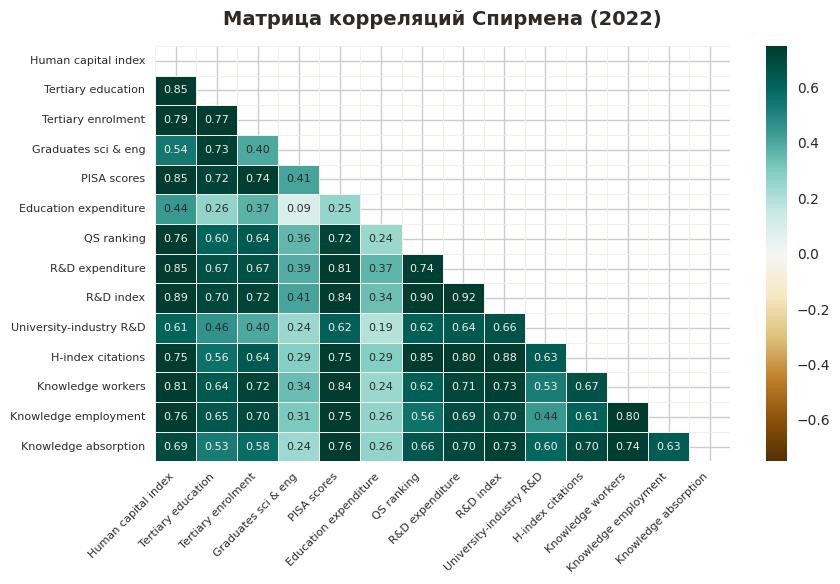

In [9]:
corr_matrix = df_work[vars_analysis].corr(method='spearman')
corr_matrix.index = vars_labels
corr_matrix.columns = vars_labels

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False,
            cmap=CMAP_DIV, vmin=-0.75, vmax=0.75, ax=ax,
            linewidths=0.4, linecolor=COLOR_LIGHT, cbar=True)

cmap_obj = plt.get_cmap(CMAP_DIV)
for i in range(len(corr_matrix)):
    for j in range(i):
        val = corr_matrix.values[i][j]
        normalized = (val + 0.75) / 1.5
        bg_color = cmap_obj(normalized)
        brightness = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
        text_color = COLOR_DARK if brightness > 0.45 else COLOR_LIGHT
        ax.text(j + 0.5, i + 0.5, f'{val:.2f}',
                ha='center', va='center', fontsize=8, color=text_color)

ax.set_title('Матрица корреляций Спирмена (2022)',
             fontsize=14, fontweight='bold', pad=15, color=COLOR_DARK)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                   fontsize=8, color=COLOR_DARK)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                   fontsize=8, color=COLOR_DARK)
plt.tight_layout()
plt.show()

На матрице хорошо видно, что большинство переменных довольно сильно коррелируют друг с другом: много значений в диапазоне от 0.6 до 0.9.

Это говорит о том, что они измеряют что-то общее, и факторный анализ здесь уместен.

Единственное исключение, это `Education expenditure`,
у нее слабые связи почти со всеми остальными переменными.

Проверим применимость факторного анализа с помощью двух тестов.

Тест Бартлетта проверяет, значимо ли переменные коррелируют между собой:
- H0: корреляционная матрица является единичной (корреляций нет, факторный анализ неприменим)
- H1: корреляционная матрица не является единичной

KMO показывает, насколько переменные связаны через общие факторы.

Значение выше 0.6 => приемлемо, выше 0.8 => хорошо.

In [10]:
chi2, p = calculate_bartlett_sphericity(df_work[vars_analysis])
print(f'Тест Бартлетта: chi2 = {round(chi2, 2)}, p-value = {round(p, 4)}')

kmo_all, kmo_model = calculate_kmo(df_work[vars_analysis])
print(f'KMO = {round(kmo_model, 3)}')

Тест Бартлетта: chi2 = 2299.47, p-value = 0.0
KMO = 0.88


- Тест Бартлетта: p < 0.001

H0 отвергается, между переменными достаточное число значимых корреляций для проведения факторного анализа.

- KMO = 0.88

Хороший результат, данные приемлемы для факторного анализа.
Можно продолжать.

Построим модель для всех 14 компонент, чтобы определить оптимальное число
компонент по правилу Кайзера:

(собственное значение > 1).

In [11]:
fa_full = FactorAnalyzer(n_factors=14, rotation='varimax', method='principal')
fa_full.fit(df_work[vars_analysis])

ev, v = fa_full.get_eigenvalues()
print('Собственные значения:')
for i, e in enumerate(ev):
    print(f'  Компонента {i+1}: {round(e, 3)}')

Собственные значения:
  Компонента 1: 8.887
  Компонента 2: 1.374
  Компонента 3: 0.958
  Компонента 4: 0.802
  Компонента 5: 0.53
  Компонента 6: 0.383
  Компонента 7: 0.344
  Компонента 8: 0.221
  Компонента 9: 0.156
  Компонента 10: 0.117
  Компонента 11: 0.107
  Компонента 12: 0.072
  Компонента 13: 0.034
  Компонента 14: 0.016


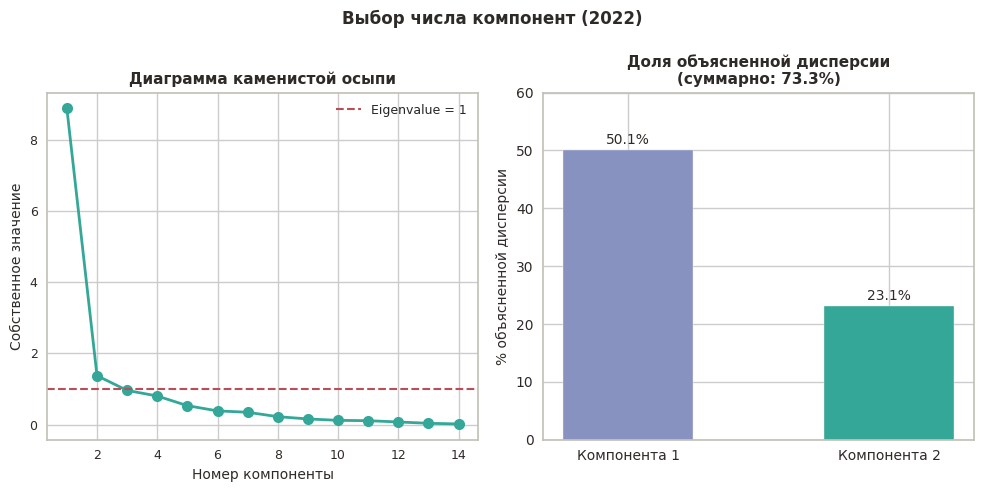

Компонента 1: 50.1% дисперсии
Компонента 2: 23.1% дисперсии
Суммарно: 73.3%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(range(1, len(ev)+1), ev, 'o-', color=C_TEAL, lw=2, markersize=8)
axes[0].axhline(y=1, color=C_RED, linestyle='--', lw=1.5, label='Eigenvalue = 1')
axes[0].set_xlabel('Номер компоненты', fontsize=10, color=COLOR_DARK)
axes[0].set_ylabel('Собственное значение', fontsize=10, color=COLOR_DARK)
axes[0].set_title('Диаграмма каменистой осыпи', fontsize=11, fontweight='bold', color=COLOR_DARK)
axes[0].legend(fontsize=9)
axes[0].tick_params(labelsize=9, colors=COLOR_DARK)
for spine in axes[0].spines.values():
    spine.set_edgecolor(C_GREY)

fa2 = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal')
fa2.fit(df_work[vars_analysis])
variance = fa2.get_factor_variance()
total_var = round(variance[1].sum()*100, 1)
var1 = round(variance[1][0]*100, 1)
var2 = round(variance[1][1]*100, 1)

bars = axes[1].bar(['Компонента 1', 'Компонента 2'],
                   [var1, var2],
                   color=COMBO_11[:2], edgecolor=COLOR_LIGHT, width=0.5)
axes[1].set_ylabel('% объясненной дисперсии', fontsize=10, color=COLOR_DARK)
axes[1].set_title(f'Доля объясненной дисперсии\n(суммарно: {total_var}%)',
                  fontsize=11, fontweight='bold', color=COLOR_DARK)
axes[1].set_ylim(0, 60)
axes[1].tick_params(labelsize=10, colors=COLOR_DARK)
for spine in axes[1].spines.values():
    spine.set_edgecolor(C_GREY)
for bar, val in zip(bars, [var1, var2]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', fontsize=10, color=COLOR_DARK)

plt.suptitle('Выбор числа компонент (2022)', fontsize=12, fontweight='bold', color=COLOR_DARK)
plt.tight_layout()
plt.show()

print(f'Компонента 1: {var1}% дисперсии')
print(f'Компонента 2: {var2}% дисперсии')
print(f'Суммарно: {total_var}%')

In [13]:
fa_final = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal')
fa_final.fit(df_work[vars_analysis])

loadings = pd.DataFrame(
    fa_final.loadings_,
    index=vars_labels,
    columns=['Компонента 1', 'Компонента 2']
).round(3)

loadings

,Компонента 1,Компонента 2
Human capital index,0.783,0.579
Tertiary education,0.368,0.890
Tertiary enrolment,0.504,0.652
Graduates sci & eng,0.014,0.855
PISA scores,0.771,0.478
Education expenditure,0.289,0.147
QS ranking,0.863,0.212
R&D expenditure,0.857,0.242
R&D index,0.939,0.236
University-industry R&D,0.736,0.144


Модель с двумя компонентами объясняет 73.3% вариации исходных переменных, что отражает хороший результат, выше порогового значения в 50%.

**Компонента 1: Научно-инновационный потенциал (50.1% дисперсии)**

На эту компоненту сильно нагружены переменные, связанные с наукой,
исследованиями и производством знаний:
- `R&D index` - (0.939),
- `H-index citations` - (0.893),
- `QS ranking` - (0.863),
- `R&D expenditure` - (0.857),
- `Knowledge workers` - (0.801),
- `PISA scores` - (0.771),
- `Knowledge absorption` - (0.770),
- `University-industry R&D` - (0.736).

Чем выше значение этой компоненты у страны, тем активнее она инвестирует
в науку, тем выше качество ее исследований и тем больше в ней людей,
занятых производством знаний. Название отражает именно эту способность
страны генерировать и применять инновации через развитую научную экосистему.

**Компонента 2: Подготовка кадров (23.1% дисперсии)**

На эту компоненту сильно нагружены переменные, связанные с охватом
высшим образованием и выпуском специалистов:
- `Tertiary education` - (0.890),
- `Graduates sci & eng` - (0.855),
- `Tertiary enrolment` - (0.652).

Компонента отражает, насколько широко в стране распространено высшее
образование, и в какой мере система готовит выпускников по естественным
наукам и инженерным специальностям. Это фундамент для будущего
инновационного развития, поскольку без подготовленных кадров невозможно
поддерживать научную активность.

Переменная `Education expenditure` показала слабые нагрузки на обе компоненты (0.289 и 0.147), что согласуется с наблюдением из матрицы корреляций: расходы на образование слабо связаны с остальными переменными и не вписываются в выявленную структуру. Тем не менее переменная остается в анализе, так как она измеряет самостоятельный аспект и будет использована отдельно при кластеризации.

In [14]:
components = pd.DataFrame(
    fa_final.transform(df_work[vars_analysis]),
    columns=['PC1_innovation', 'PC2_education'],
    index=df_work.index
)

df_work = pd.concat([df_work, components], axis=1)
print(f'Датасет обновлен: {df_work.shape[0]} стран, {df_work.shape[1]} столбцов')
df_work[['Country', 'PC1_innovation', 'PC2_education']].head(10)

Датасет обновлен: 132 стран, 17 столбцов


,Country,PC1_innovation,PC2_education
0,Cote d'Ivoire,-0.410972,-1.546676
1,Czechia,0.598629,0.780886
2,"Egypt, Arab Rep.",-0.009055,-1.178987
3,"Hong Kong SAR, China",1.644774,-0.151166
4,"Iran, Islamic Rep.",-1.149272,1.668300
5,"Korea, Rep.",2.136111,0.672442
6,Lao PDR,-0.957258,-0.287544
7,Myanmar,-1.581664,0.767976
8,Russian Federation,0.338833,1.411532
9,Slovak Republic,-0.093113,0.460162


2. Сформируйте финальный список переменных по которым будет проведена кластеризация. Это могут быть:
- только исходные переменные,
- только сформированные компоненты,
- комбинация из исходных переменных (по которым не удалось сформировать компоненты) и компонентов.

Приведите аргументы в пользу того, что финальный список переменных может быть использован для кластеризации объектов наблюдения.

## Задание 2. Финальный список переменных для кластеризации

Поскольку между исходными переменными наблюдались значимые корреляции, для кластеризации используем компоненты, а не исходные переменные. Это
позволит избежать искажения результатов из-за мультиколлинеарности.

Переменная `Education expenditure` не вошла ни в одну из компонент, измеряет самостоятельный аспект и добавляется к финальному списку отдельно.

Итоговый список переменных для кластеризации:
- `PC1_innovation` - Научно-инновационный потенциал
- `PC2_education` - Подготовка кадров  
- `Education expenditure` - Расходы на образование, % ВВП

In [15]:
cluster_vars = ['PC1_innovation', 'PC2_education',
                'Expenditure on education, % GDP_2022']

df_cluster = df_work[['Country'] + cluster_vars].dropna().reset_index(drop=True)
print(f'Стран для кластеризации: {df_cluster.shape[0]}')
df_cluster.head(5)

Стран для кластеризации: 132


,Country,PC1_innovation,PC2_education,"Expenditure on education, % GDP_2022"
0,Cote d'Ivoire,-0.410972,-1.546676,25.5
1,Czechia,0.598629,0.780886,35.4
2,"Egypt, Arab Rep.",-0.009055,-1.178987,13.9
3,"Hong Kong SAR, China",1.644774,-0.151166,37.0
4,"Iran, Islamic Rep.",-1.149272,1.668300,27.3


In [16]:
df_cluster[cluster_vars].describe().round(2)

,PC1_innovation,PC2_education,"Expenditure on education, % GDP_2022"
count,132.00,132.00,132.00
mean,0.00,0.00,36.61
std,1.00,1.00,18.98
min,-1.58,-1.85,0.00
25%,-0.65,-0.80,24.18
50%,-0.33,0.15,35.30
75%,0.34,0.68,47.32
max,3.09,2.62,100.00


In [17]:
df_cluster = df_cluster.rename(columns={
    'Expenditure on education, % GDP_2022': 'Education_expenditure'
})

cluster_vars = ['PC1_innovation', 'PC2_education', 'Education_expenditure']
print(df_cluster.columns.tolist())
df_cluster.head(3)

['Country', 'PC1_innovation', 'PC2_education', 'Education_expenditure']


,Country,PC1_innovation,PC2_education,Education_expenditure
0,Cote d'Ivoire,-0.410972,-1.546676,25.5
1,Czechia,0.598629,0.780886,35.4
2,"Egypt, Arab Rep.",-0.009055,-1.178987,13.9


3. Выберите подходящий алгоритм кластеризации и обоснуйте свой выбор. Определите число кластеров, объясните своё решение. Опишите получившиеся кластеры с помощью описательной статистки. Нужно не просто рассчитать статистики в таблицах, но детально описать полученные результаты. Дайте названия кластерам и обоснуйте их.

## Задание 3. Кластеризация

Перед кластеризацией стандартизируем переменные. Компоненты уже стандартизированы по своей природе, но `Education expenditure` измеряется в других единицах, поэтому приводим все к единой шкале.

In [18]:
df_scaled = df_cluster.copy()
df_scaled[cluster_vars] = df_scaled[cluster_vars].apply(zscore)
df_scaled.head(3)

,Country,PC1_innovation,PC2_education,Education_expenditure
0,Cote d'Ivoire,-0.410972,-1.546676,-0.587519
1,Czechia,0.598629,0.780886,-0.063873
2,"Egypt, Arab Rep.",-0.009055,-1.178987,-1.201085


Для кластеризации выберем алгоритм K-means. Все три переменные метрические, а выборка из 132 стран составляет подходящий размер для этого алгоритма. Результаты удобно интерпретировать через средние значения переменных внутри каждого кластера.

In [19]:
Z = linkage(df_scaled[cluster_vars].values, method='ward', metric='euclidean')

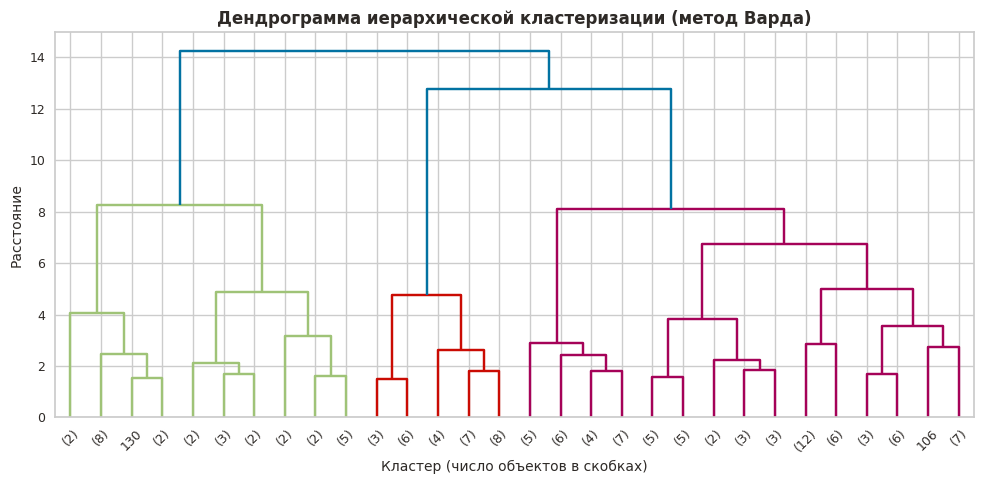

In [20]:
plt.figure(figsize=(10, 5))
dn = dendrogram(Z, truncate_mode='lastp', p=30,
                leaf_rotation=45, leaf_font_size=9,
                color_threshold=0.7*max(Z[:,2]))
plt.title('Дендрограмма иерархической кластеризации (метод Варда)',
          fontsize=12, fontweight='bold', color=COLOR_DARK)
plt.xlabel('Кластер (число объектов в скобках)', fontsize=10, color=COLOR_DARK)
plt.ylabel('Расстояние', fontsize=10, color=COLOR_DARK)
plt.tick_params(labelsize=9, colors=COLOR_DARK)
plt.tight_layout()
plt.show()

Перед K-means была проведена иерархическая кластеризация методом Варда, чтобы визуально оценить структуру данных через дендрограмму. На ней видны 4 основные ветки.

In [21]:
X = df_scaled[cluster_vars].values

ks = range(2, 10)
ch_scores = []
sil_scores = []

for k in ks:
    labels = fcluster(Z, t=k, criterion='maxclust')
    ch_scores.append(calinski_harabasz_score(X, labels))
    sil_scores.append(silhouette_score(X, labels))
    print(f'Число кластеров: {k}, '
          f'Calinski-Harabasz: {calinski_harabasz_score(X, labels):.2f}, '
          f'Silhouette: {silhouette_score(X, labels):.3f}')

Число кластеров: 2, Calinski-Harabasz: 44.95, Silhouette: 0.310
Число кластеров: 3, Calinski-Harabasz: 55.47, Silhouette: 0.294
Число кластеров: 4, Calinski-Harabasz: 51.80, Silhouette: 0.288
Число кластеров: 5, Calinski-Harabasz: 54.29, Silhouette: 0.264
Число кластеров: 6, Calinski-Harabasz: 55.65, Silhouette: 0.282
Число кластеров: 7, Calinski-Harabasz: 53.52, Silhouette: 0.248
Число кластеров: 8, Calinski-Harabasz: 53.08, Silhouette: 0.257
Число кластеров: 9, Calinski-Harabasz: 53.98, Silhouette: 0.263


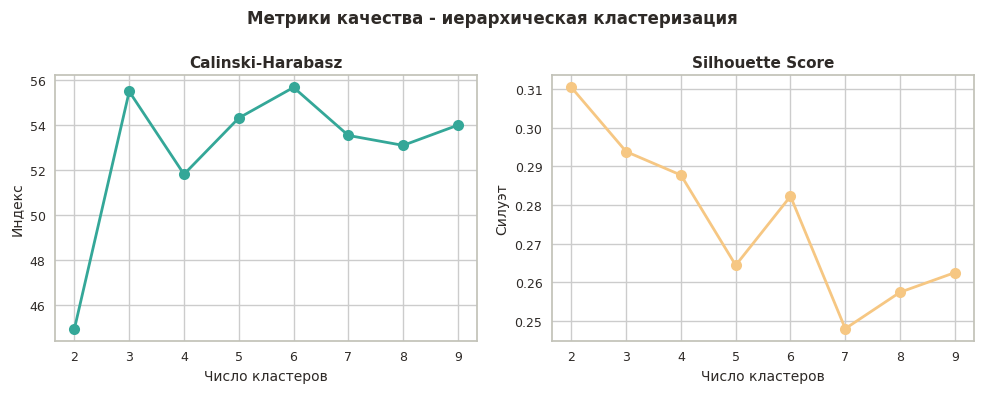

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(ks, ch_scores, 'o-', color=C_TEAL, lw=2, markersize=8)
axes[0].set_title('Calinski-Harabasz', fontsize=11, fontweight='bold', color=COLOR_DARK)
axes[0].set_xlabel('Число кластеров', fontsize=10, color=COLOR_DARK)
axes[0].set_ylabel('Индекс', fontsize=10, color=COLOR_DARK)
axes[0].tick_params(labelsize=9, colors=COLOR_DARK)
for spine in axes[0].spines.values():
    spine.set_edgecolor(C_GREY)

axes[1].plot(ks, sil_scores, 'o-', color=C_YELLOW, lw=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=11, fontweight='bold', color=COLOR_DARK)
axes[1].set_xlabel('Число кластеров', fontsize=10, color=COLOR_DARK)
axes[1].set_ylabel('Силуэт', fontsize=10, color=COLOR_DARK)
axes[1].tick_params(labelsize=9, colors=COLOR_DARK)
for spine in axes[1].spines.values():
    spine.set_edgecolor(C_GREY)

plt.suptitle('Метрики качества - иерархическая кластеризация',
             fontsize=12, fontweight='bold', color=COLOR_DARK)
plt.tight_layout()
plt.show()

Метрики дают неоднозначный сигнал: Calinski-Harabasz максимален при 3 и 6
кластерах, Silhouette при 2, но в целом невысок (ниже 0.5).
По дендрограмме видны 4 основные ветки.

Рассмотрим диапазон 3-5 кластеров и примем решение после анализа K-means.

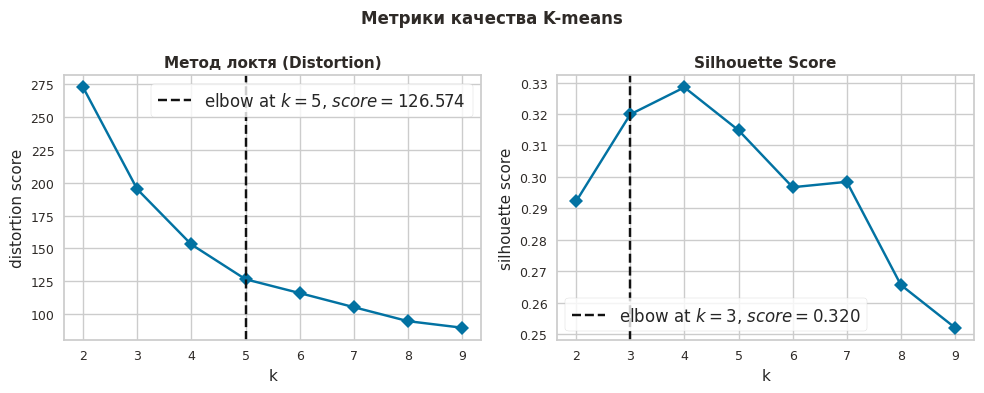

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

model_distortion = KMeans(random_state=42)
visualizer_distortion = KElbowVisualizer(model_distortion, k=(2, 10),
                                          timings=False, ax=axes[0])
visualizer_distortion.fit(X)
visualizer_distortion.finalize()
axes[0].set_title('Метод локтя (Distortion)', fontsize=11,
                  fontweight='bold', color=COLOR_DARK)
axes[0].tick_params(labelsize=9, colors=COLOR_DARK)

model_silhouette = KMeans(random_state=42)
visualizer_silhouette = KElbowVisualizer(model_silhouette, k=(2, 10),
                                          metric='silhouette',
                                          timings=False, ax=axes[1])
visualizer_silhouette.fit(X)
visualizer_silhouette.finalize()
axes[1].set_title('Silhouette Score', fontsize=11,
                  fontweight='bold', color=COLOR_DARK)
axes[1].tick_params(labelsize=9, colors=COLOR_DARK)

plt.suptitle('Метрики качества K-means',
             fontsize=12, fontweight='bold', color=COLOR_DARK)
plt.tight_layout()
plt.show()

In [24]:
for n_clusters in [3, 4, 5]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X)
    print(f'\nK = {n_clusters}:')
    unique, counts = np.unique(labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        print(f'  Кластер {cluster+1}: {count} стран')


K = 3:
  Кластер 1: 57 стран
  Кластер 2: 44 стран
  Кластер 3: 31 стран

K = 4:
  Кластер 1: 53 стран
  Кластер 2: 34 стран
  Кластер 3: 20 стран
  Кластер 4: 25 стран

K = 5:
  Кластер 1: 22 стран
  Кластер 2: 32 стран
  Кластер 3: 41 стран
  Кластер 4: 15 стран
  Кластер 5: 22 стран


In [25]:
kmeans_final = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans_final.fit_predict(X) + 1

print('Число стран в каждом кластере:')
print(df_cluster['cluster'].value_counts().sort_index())

Число стран в каждом кластере:
cluster
1    53
2    34
3    20
4    25
Name: count, dtype: int64


Для выбора числа кластеров использовались две метрики: метод локтя указал на 5, Silhouette на 3. Метрики иерархической кластеризации тоже не дали однозначного ответа. С учетом дендрограммы и наполненности решено остановиться на 4 кластерах, где в каждом не менее 20 стран, что позволит содержательно их описать.

In [26]:
# Добавим метки кластеров в рабочий датасет
df_work['cluster'] = df_cluster['cluster'].values

# Описательная статистика по кластерам
cluster_profile = df_work.groupby('cluster')[vars_analysis].mean().round(2).T
cluster_profile.columns = ['Кластер 1', 'Кластер 2', 'Кластер 3', 'Кластер 4']
cluster_profile.index = vars_labels
cluster_profile

,Кластер 1,Кластер 2,Кластер 3,Кластер 4
Human capital index,33.54,15.33,30.74,55.72
Tertiary education,37.47,8.34,25.72,41.14
Tertiary enrolment,35.02,8.43,28.56,49.22
Graduates sci & eng,56.22,7.56,32.03,43.30
PISA scores,33.17,1.64,15.16,69.21
Education expenditure,29.26,24.90,63.64,46.48
QS ranking,16.01,3.04,9.15,63.17
R&D expenditure,11.92,2.92,8.82,46.68
R&D index,13.49,1.76,8.67,63.26
University-industry R&D,43.73,35.29,40.36,62.50


In [27]:
for cluster_num in [1, 2, 3, 4]:
    countries = df_cluster[df_cluster['cluster'] == cluster_num]['Country'].tolist()
    print(f'\nКластер {cluster_num} (количество стран - {len(countries)}):')
    print(', '.join(countries))


Кластер 1 (количество стран - 53):
Czechia, Iran, Islamic Rep., Myanmar, Russian Federation, Slovak Republic, Turkiye, Madagascar, Mauritania, Mauritius, Zimbabwe, Bahrain, Jordan, Oman, Qatar, United Arab Emirates, Albania, Azerbaijan, Belarus, Bosnia and Herzegovina, Bulgaria, Croatia, Estonia, Georgia, Greece, Latvia, Lithuania, Luxembourg, Malta, Montenegro, North Macedonia, Portugal, Romania, Serbia, Slovenia, Ukraine, Brunei Darussalam, Cambodia, India, Kazakhstan, Malaysia, Mongolia, Philippines, Singapore, Thailand, Uzbekistan, Vietnam, Argentina, Colombia, El Salvador, Mexico, Panama, Peru, Uruguay

Кластер 2 (количество стран - 34):
Cote d'Ivoire, Egypt, Arab Rep., Lao PDR, Yemen, Rep., Angola, Benin, Burundi, Cameroon, Ethiopia, Ghana, Guinea, Kenya, Mali, Niger, Nigeria, Rwanda, Senegal, Tanzania, Togo, Uganda, Zambia, Iraq, Armenia, Bangladesh, Indonesia, Nepal, Pakistan, Sri Lanka, Dominican Republic, Ecuador, Guatemala, Nicaragua, Paraguay, Trinidad and Tobago

Кластер 

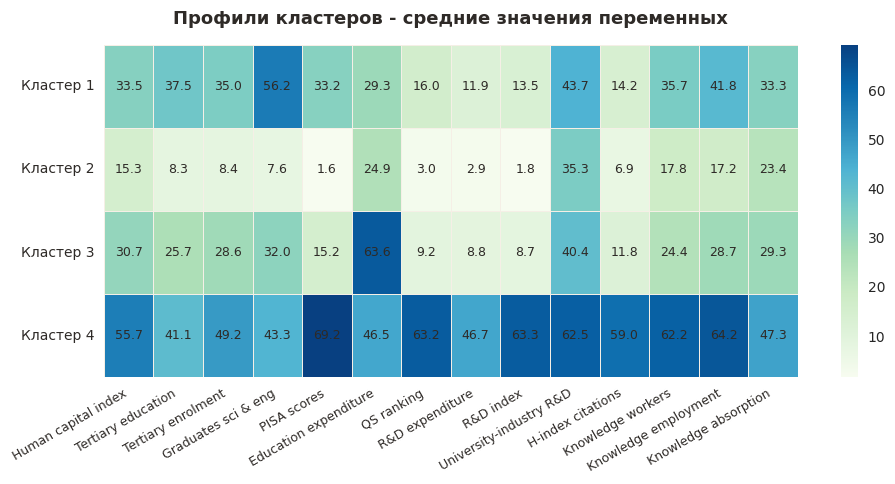

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(cluster_profile.T, annot=True, fmt='.1f',
            cmap=CMAP_SEQ, ax=ax,
            linewidths=0.4, linecolor=COLOR_LIGHT,
            annot_kws={'size': 9, 'color': COLOR_DARK})

ax.set_title('Профили кластеров - средние значения переменных',
             fontsize=13, fontweight='bold', color=COLOR_DARK, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right',
                   fontsize=9, color=COLOR_DARK)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                   fontsize=10, color=COLOR_DARK)
plt.tight_layout()
plt.show()

Поскольку переменные измеряются в разных шкалах, дополнительно
посмотрим на профили кластеров по стандартизированным переменным,
которые использовались при кластеризации.

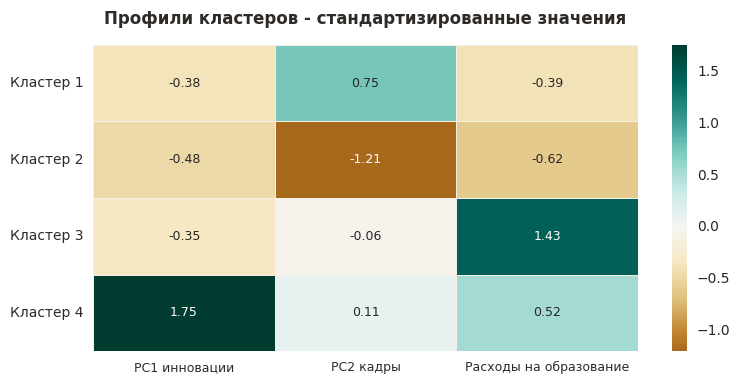

In [29]:
cluster_profile_scaled = df_scaled.copy()
cluster_profile_scaled['cluster'] = df_cluster['cluster'].values
cluster_profile_scaled = cluster_profile_scaled.groupby('cluster')[cluster_vars].mean().round(2)
cluster_profile_scaled.index = ['Кластер 1', 'Кластер 2', 'Кластер 3', 'Кластер 4']

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cluster_profile_scaled, annot=True, fmt='.2f',
            cmap=CMAP_DIV, ax=ax, center=0,
            linewidths=0.4, linecolor=COLOR_LIGHT,
            annot_kws={'size': 9})
ax.set_title('Профили кластеров - стандартизированные значения',
             fontsize=12, fontweight='bold', color=COLOR_DARK, pad=15)
ax.set_xticklabels(['PC1 инновации', 'PC2 кадры', 'Расходы на образование'],
                   fontsize=9, color=COLOR_DARK)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10, color=COLOR_DARK)
plt.tight_layout()
plt.show()

По стандартизированным значениям хорошо видны отличительные черты каждого кластера.

Кластер 4 резко выделяется по научно-инновационному потенциалу (PC1 = 1.75), Кластер 3 исключительно по расходам на образование (1.43), Кластер 1 по подготовке кадров (0.75), Кластер 2 отстает по всем трем переменным.

На графике ниже посмотрим как эти различия проявляются в пространстве двух главных компонент.

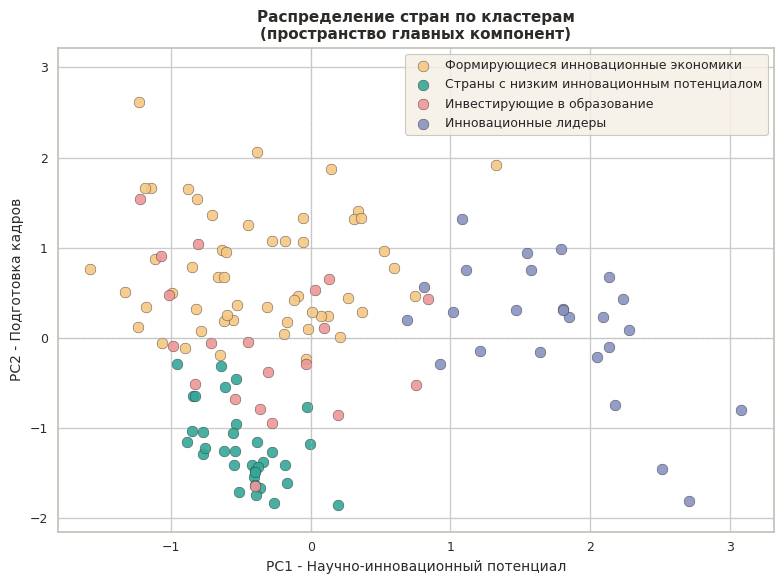

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))

cluster_colors = {1: C_YELLOW, 2: C_TEAL, 3: C_PINK, 4: C_LILAC}
cluster_names = {
    1: 'Формирующиеся инновационные экономики',
    2: 'Страны с низким инновационным потенциалом',
    3: 'Инвестирующие в образование',
    4: 'Инновационные лидеры'
}

for cluster_num in [1, 2, 3, 4]:
    mask = df_cluster['cluster'] == cluster_num
    ax.scatter(df_cluster[mask]['PC1_innovation'],
               df_cluster[mask]['PC2_education'],
               c=cluster_colors[cluster_num],
               label=cluster_names[cluster_num],
               s=60, alpha=0.9, edgecolors=COLOR_DARK, linewidths=0.3)

ax.set_xlabel('PC1 - Научно-инновационный потенциал',
              fontsize=10, color=COLOR_DARK)
ax.set_ylabel('PC2 - Подготовка кадров',
              fontsize=10, color=COLOR_DARK)
ax.set_title('Распределение стран по кластерам\n(пространство главных компонент)',
             fontsize=11, fontweight='bold', color=COLOR_DARK)

legend = ax.legend(fontsize=9, loc='upper right',
                   framealpha=0.85, facecolor=COLOR_LIGHT,
                   edgecolor=C_GREY, frameon=True)
legend.get_frame().set_linewidth(0.8)
legend.set_zorder(10)

ax.set_ylim(df_cluster['PC2_education'].min() - 0.3,
            df_cluster['PC2_education'].max() + 0.6)

ax.tick_params(labelsize=9, colors=COLOR_DARK)
ax.axhline(y=0, color=C_GREY, linestyle='--', lw=0.8, alpha=0.5)
ax.axvline(x=0, color=C_GREY, linestyle='--', lw=0.8, alpha=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor(C_GREY)
plt.tight_layout()
plt.show()

- На графике видно, что Кластер 4 (лиловый) сдвинут вправо: высокий научно-инновационный потенциал отделяет лидеров от остальных.

- Кластер 2 (бирюзовый) сконцентрирован внизу слева: низкие значения по обеим компонентам.

- Кластер 1 (желтый) занимает центральную и верхнюю часть: средний инновационный потенциал при относительно высокой подготовке кадров.

- Кластер 3 (розовый) размыт по всему пространству, что объясняется его спецификой: он выделяется по `Education expenditure`, которая не отражена на осях этого графика.

Поскольку кластеризация проводилась по трем переменным, построим трехмерный scatter plot. Он позволит увидеть расположение кластеров по всем трем переменным одновременно и объяснит почему Кластер 3 сложно выделить на двумерном графике.

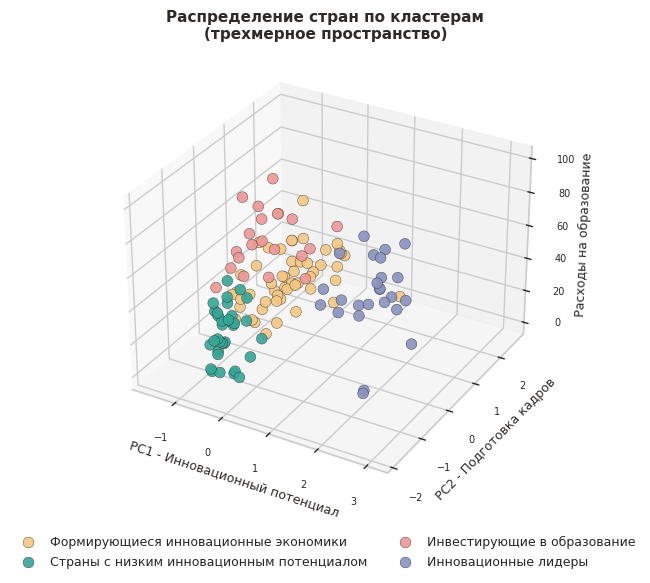

In [77]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

cluster_colors = {1: C_YELLOW, 2: C_TEAL, 3: C_PINK, 4: C_LILAC}
cluster_names = {
    1: 'Формирующиеся инновационные экономики',
    2: 'Страны с низким инновационным потенциалом',
    3: 'Инвестирующие в образование',
    4: 'Инновационные лидеры'
}

for cluster_num in [1, 2, 3, 4]:
    mask = df_cluster['cluster'] == cluster_num
    ax.scatter(df_cluster[mask]['PC1_innovation'],
               df_cluster[mask]['PC2_education'],
               df_cluster[mask]['Education_expenditure'],
               c=cluster_colors[cluster_num],
               label=cluster_names[cluster_num],
               s=60, alpha=0.9, edgecolors=COLOR_DARK, linewidths=0.3)

ax.set_xlabel('PC1 - Инновационный потенциал', fontsize=9, color=COLOR_DARK)
ax.set_ylabel('PC2 - Подготовка кадров', fontsize=9, color=COLOR_DARK)
ax.set_zlabel('Расходы на образование', fontsize=9, color=COLOR_DARK)
ax.set_title('Распределение стран по кластерам\n(трехмерное пространство)',
             fontsize=11, fontweight='bold', color=COLOR_DARK)
ax.legend(fontsize=9,
          framealpha=0.85, facecolor=COLOR_LIGHT,
          edgecolor=C_GREY,
          bbox_to_anchor=(0.5, -0.05),
          loc='upper center',
          ncol=2)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

- На трехмерном графике хорошо видно, что Кластер 3 (розовый) занимает верхнюю часть по оси расходов на образование, при этом оставаясь в центре по двум другим осям. Именно это делало его незаметным на двумерном графике: по PC1 и PC2 он не выделяется, но по третьей переменной четко отличается от остальных кластеров.

- Кластер 4 (лиловый) сдвинут вправо по оси инновационного потенциала.

- Кластер 2 (бирюзовый) сконцентрирован в нижнем левом углу.

- Кластер 1 (желтый) занимает центральную область, он самый многочисленный и наименее однородный по расположению в пространстве.

Это подтверждает содержательную интерпретацию: страны различаются не только по уровню инновационного развития, но и по тому, как они к нему приходят. Одни инвестируют в науку и получают результат, другие много тратят на образование, но пока не конвертируют эти вложения в инновационный потенциал. Третьи находятся в процессе формирования научной базы, готовя кадры, но не имея еще достаточно ресурсов для полноценной исследовательской деятельности.

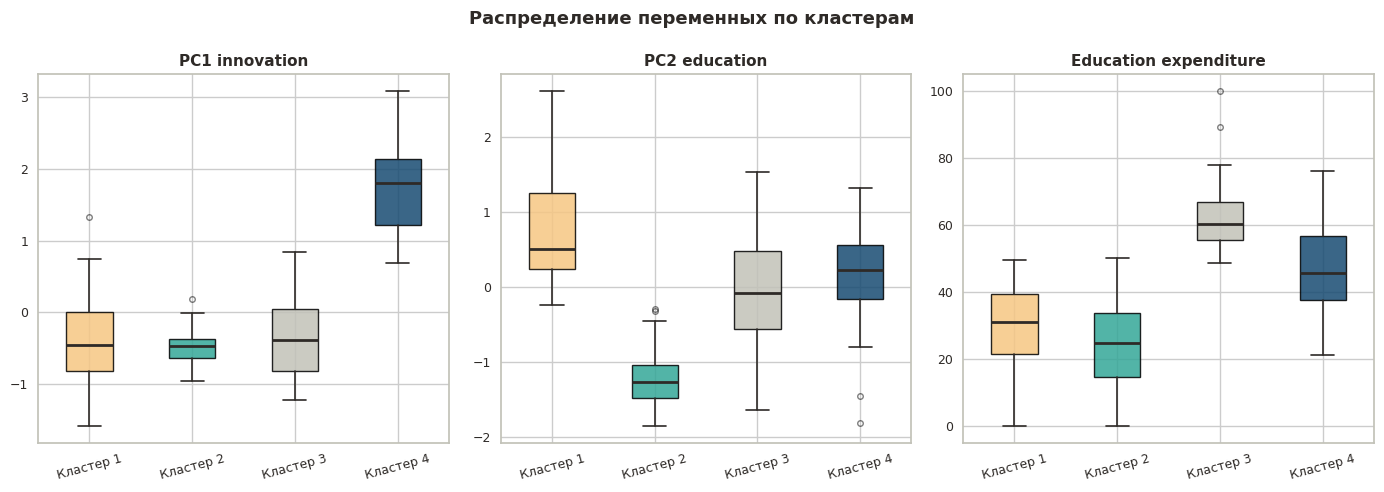

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, var in enumerate(cluster_vars):
    data_by_cluster = [df_cluster[df_cluster['cluster'] == c][var].values
                       for c in [1, 2, 3, 4]]

    bp = axes[idx].boxplot(data_by_cluster,
                           patch_artist=True,
                           medianprops=dict(color=COLOR_DARK, lw=2),
                           whiskerprops=dict(color=COLOR_DARK, lw=1.2),
                           capprops=dict(color=COLOR_DARK, lw=1.2),
                           flierprops=dict(marker='o', markersize=4, alpha=0.5))

    for patch, color in zip(bp['boxes'], COMBO_4):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    axes[idx].set_title(var.replace('_', ' '), fontsize=11,
                        fontweight='bold', color=COLOR_DARK)
    axes[idx].set_xticklabels(['Кластер 1', 'Кластер 2',
                                'Кластер 3', 'Кластер 4'],
                               fontsize=9, color=COLOR_DARK, rotation=15)
    axes[idx].tick_params(labelsize=9, colors=COLOR_DARK)
    for spine in axes[idx].spines.values():
        spine.set_edgecolor(C_GREY)

plt.suptitle('Распределение переменных по кластерам',
             fontsize=13, fontweight='bold', color=COLOR_DARK)
plt.tight_layout()
plt.show()

**Кластер 4: Инновационные лидеры (25 стран)**

Страны этого кластера демонстрируют наивысшие значения по всем показателям:
научно-инновационный потенциал (PC1 = 1.75), расходы на R&D, цитируемость,
рейтинги университетов.

В среднем по кластеру:
- `R&D index` = 63.26,
- `H-index citations` = 58.96,
- `QS ranking` = 63.17,
- `R&D expenditure` = 46.68,
- `PISA scores` = 69.21.

В этот кластер входят развитые страны Западной Европы, США, Канада, Австралия, Япония, Корея. Название отражает их лидирующую роль в мировой науке и инновациях.

**Кластер 1: Формирующиеся инновационные экономики (53 страны)**
Это самый многочисленный кластер. Выделяется высоким значением по подготовке
кадров (PC2 = 0.75), особенно по доле выпускников в области науки и
инженерии.

В среднем по кластеру:
- `Graduates sci & eng` = 56.22,
- `Tertiary enrolment` = 35.02,
- `PC2 education` = 0.75.

Однако
- `R&D index` = 13.49 и
- `H-index citations` = 14.22 заметно ниже чем у лидеров.

Это страны Восточной Европы, Юго-Восточной Азии, Персидского залива
и Латинской Америки, которые активно готовят специалистов, но пока
уступают лидерам по научной активности.

**Кластер 3: Инвестирующие в образование (20 стран)**
Единственный отличительный признак этого кластера – высокие расходы на образование.

- Среднее значение `Education expenditure` = 63.64, наивысшее среди всех кластеров.

Однако

- `R&D index` = 8.67,
- `H-index citations` = 11.76 на уровне аутсайдеров.

При этом научно-инновационный потенциал и подготовка кадров остаются на среднем уровне. В кластер вошли страны с высокими нефтяными доходами (Саудовская Аравия, Кувейт), а также ряд африканских и латиноамериканских стран. Высокие расходы на образование пока не конвертируются в сопоставимые результаты.

**Кластер 2: Страны с низким инновационным потенциалом (34 страны)**
Наиболее низкие значения по всем трем переменным, особенно по подготовке
кадров (PC2 = -1.21).

В среднем по кластеру:
- `R&D index` = 1.76,
- `H-index citations` = 6.89,
- `PISA scores` = 1.64,
- `Education expenditure` = 24.90.

Это преимущественно страны Африки и беднейшие
страны Азии и Латинской Америки. Ограниченные ресурсы не позволяют
инвестировать ни в образование, ни в науку.



---





---

---





---



### Дополнительно: DBSCAN

DBSCAN, это плотностный алгоритм, который в отличие от K-means не требует задавать число кластеров заранее, а также умеет выявлять выбросы, помещая их в отдельный кластер с меткой -1.

Применим его для сравнения с K-means и проверки устойчивости результатов.

In [33]:
# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'Число кластеров: {n_clusters}')
print(f'Выбросов (шум): {n_noise}')
print(f'Распределение по кластерам:')
for label in sorted(set(dbscan_labels)):
    count = list(dbscan_labels).count(label)
    name = 'Выбросы' if label == -1 else f'Кластер {label+1}'
    print(f'  {name}: {count} стран')

Число кластеров: 1
Выбросов (шум): 10
Распределение по кластерам:
  Выбросы: 10 стран
  Кластер 1: 122 стран


In [34]:
print('eps  | min_samples | кластеров | выбросов')
print('-' * 45)
for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]:
    for min_samples in [3, 4, 5]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if 2 <= n_clusters <= 6:
            print(f'{eps:.1f}  | {min_samples}           | {n_clusters}         | {n_noise}')

eps  | min_samples | кластеров | выбросов
---------------------------------------------
0.3  | 4           | 2         | 121
0.3  | 5           | 2         | 121
0.4  | 4           | 4         | 97
0.4  | 5           | 3         | 103
0.5  | 4           | 5         | 59
0.5  | 5           | 4         | 80
0.6  | 3           | 3         | 24
0.6  | 4           | 2         | 32
0.6  | 5           | 2         | 45
0.7  | 3           | 2         | 13
0.7  | 4           | 2         | 16
0.7  | 5           | 2         | 27


In [35]:
dbscan_final = DBSCAN(eps=0.6, min_samples=3)
dbscan_labels = dbscan_final.fit_predict(X)

df_cluster['cluster_dbscan'] = dbscan_labels

print('Распределение по кластерам:')
for label in sorted(set(dbscan_labels)):
    count = list(dbscan_labels).count(label)
    name = 'Выбросы' if label == -1 else f'Кластер {label+1}'
    countries = df_cluster[df_cluster['cluster_dbscan'] == label]['Country'].tolist()
    print(f'\n{name} (количество стран — {count}):')
    print(', '.join(countries))

Распределение по кластерам:

Выбросы (количество стран — 24):
Botswana, Namibia, Algeria, Israel, Oman, Saudi Arabia, Tunisia, Austria, Belarus, Belgium, Denmark, Finland, Iceland, Moldova, Norway, Sweden, Ukraine, China, Japan, New Zealand, Pakistan, Singapore, Brazil, United States

Кластер 1 (количество стран — 97):
Cote d'Ivoire, Czechia, Egypt, Arab Rep., Hong Kong SAR, China, Iran, Islamic Rep., Lao PDR, Myanmar, Russian Federation, Slovak Republic, Turkiye, Yemen, Rep., Angola, Benin, Burkina Faso, Burundi, Cameroon, Ethiopia, Ghana, Guinea, Kenya, Madagascar, Mali, Mauritania, Mauritius, Mozambique, Niger, Nigeria, Rwanda, Senegal, South Africa, Tanzania, Togo, Uganda, Zambia, Zimbabwe, Bahrain, Iraq, Jordan, Qatar, United Arab Emirates, Albania, Armenia, Azerbaijan, Bosnia and Herzegovina, Bulgaria, Croatia, Cyprus, Estonia, Georgia, Greece, Hungary, Ireland, Italy, Latvia, Lithuania, Luxembourg, Malta, Montenegro, North Macedonia, Poland, Portugal, Romania, Serbia, Slovenia, 

In [36]:
# Иерархический
labels_hier = fcluster(Z, t=4, criterion='maxclust')
sil_hier = silhouette_score(X, labels_hier)

# K-means
sil_kmeans = silhouette_score(X, df_cluster['cluster'].values)

# DBSCAN - исключаем выбросы из расчета
mask_no_noise = df_cluster['cluster_dbscan'] != -1
sil_dbscan = silhouette_score(X[mask_no_noise],
                               dbscan_labels[mask_no_noise])

print('Сравнение алгоритмов:')
print(f'{'Алгоритм':<25} {'Силуэт':>10} {'Кластеров':>12} {'Выбросов':>10}')
print('-' * 60)
print(f'{'Иерархический (Вард)':<25} {sil_hier:>10.3f} {4:>12} {0:>10}')
print(f'{'K-means':<25} {sil_kmeans:>10.3f} {4:>12} {0:>10}')
print(f'{'DBSCAN':<25} {sil_dbscan:>10.3f} {3:>12} {24:>10}')

Сравнение алгоритмов:
Алгоритм                      Силуэт    Кластеров   Выбросов
------------------------------------------------------------
Иерархический (Вард)           0.288            4          0
K-means                        0.328            4          0
DBSCAN                         0.162            3         24


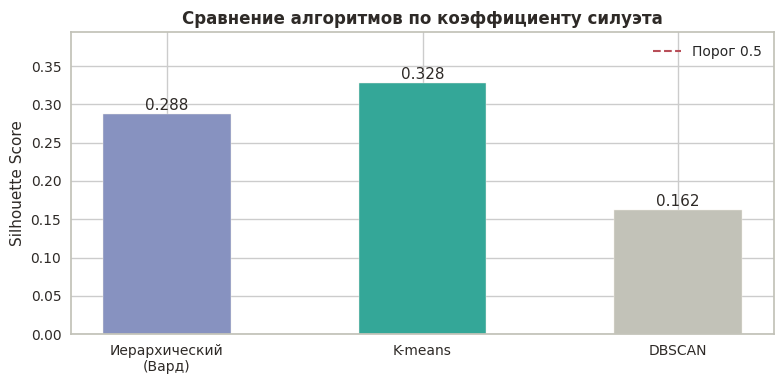

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

algorithms = ['Иерархический\n(Вард)', 'K-means', 'DBSCAN']
sil_values = [sil_hier, sil_kmeans, sil_dbscan]

bars = ax.bar(algorithms, sil_values,
              color=COMBO_11, edgecolor=COLOR_LIGHT, width=0.5)
for bar, val in zip(bars, sil_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, color=COLOR_DARK)

ax.set_ylim(0, max(sil_values) * 1.2)
ax.axhline(y=0.5, color=C_RED, linestyle='--', lw=1.5, label='Порог 0.5')
ax.set_title('Сравнение алгоритмов по коэффициенту силуэта',
             fontsize=12, fontweight='bold', color=COLOR_DARK)
ax.set_ylabel('Silhouette Score', fontsize=11, color=COLOR_DARK)
ax.tick_params(labelsize=10, colors=COLOR_DARK)
ax.legend(fontsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor(C_GREY)
plt.tight_layout()
plt.show()

Были применены три алгоритма кластеризации, пройденных на занятиях:
иерархический (метод Варда), K-means и DBSCAN.

По коэффициенту силуэта лучший результат показал K-means (0.328),
иерархический незначительно уступает (0.288), DBSCAN заметно хуже (0.162).
Все три значения ниже порога 0.5, что типично для реальных социально-экономических данных без четко выраженных границ между группами.

DBSCAN оказался наименее подходящим для этой задачи: он объединил 97 из 132 стран в один кластер и отнес к выбросам 24 страны, включая США, Японию и Финляндию, то есть очевидных инновационных лидеров. Это говорит о том, что данные не имеют выраженной плотностной структуры, на которую рассчитан DBSCAN.

Иерархический алгоритм был полезен на этапе разведочного анализа, так как
дендрограмма помогла визуально оценить структуру данных и сформировать
гипотезу о числе кластеров. Однако как финальная модель он уступает K-means.

K-means выбран как финальный алгоритм: он дал наилучший силуэт,
сбалансированные по размеру кластеры (20-53 страны) и результаты,
которые содержательно хорошо интерпретируются.

4. Проведите апостериорный анализ данных на основе категориальных переменных датасета. Например, рассмотрите как распределены страны разных регионов по кластерам или в какие кластеры в основном попали страны-члены ОЭСР?

## Задание 4. Апостериорный анализ

Сначала подготовим данные: добавим категориальные переменные из исходного датасета.

In [38]:
df_cluster['Region2'] = df[df['Country'].isin(df_cluster['Country'])]['Region2'].values
df_cluster['Income'] = df[df['Country'].isin(df_cluster['Country'])]['Income'].values
df_cluster['OECD members'] = df[df['Country'].isin(df_cluster['Country'])]['OECD members'].values
df_cluster[['Country', 'cluster', 'Region2', 'Income', 'OECD members']].head(5)

,Country,cluster,Region2,Income,OECD members
0,Cote d'Ivoire,2,Sub-Saharan Africa,middle income,0
1,Czechia,1,Europe,high income,1
2,"Egypt, Arab Rep.",2,Middle East and North Africa,middle income,0
3,"Hong Kong SAR, China",4,Asia-Pacific,high income,0
4,"Iran, Islamic Rep.",1,Middle East and North Africa,middle income,0


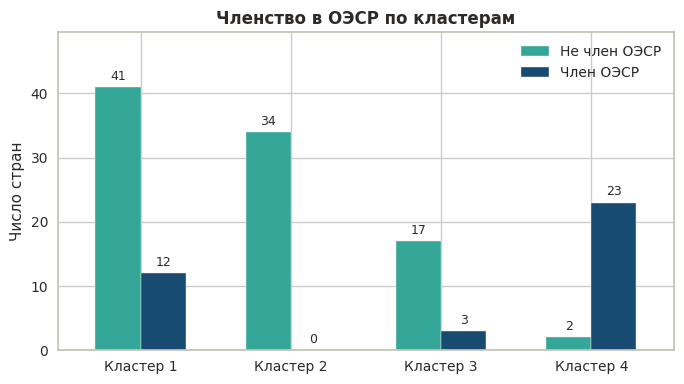

In [39]:
# OECD members
oecd_crosstab = pd.crosstab(df_cluster['cluster'], df_cluster['OECD members'])
oecd_crosstab.columns = ['Не член ОЭСР', 'Член ОЭСР']
oecd_crosstab.index = ['Кластер 1', 'Кластер 2', 'Кластер 3', 'Кластер 4']

fig, ax = plt.subplots(figsize=(7, 4))
oecd_crosstab.plot(kind='bar', ax=ax, color=COMBO_1[:2],
                   edgecolor=COLOR_LIGHT, width=0.6)
for container in ax.containers:
    ax.bar_label(container, fontsize=9, color=COLOR_DARK, padding=3)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.set_title('Членство в ОЭСР по кластерам',
             fontsize=12, fontweight='bold', color=COLOR_DARK)
ax.set_ylabel('Число стран', fontsize=11, color=COLOR_DARK)
ax.tick_params(labelsize=10, colors=COLOR_DARK)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor(C_GREY)
plt.tight_layout()
plt.show()

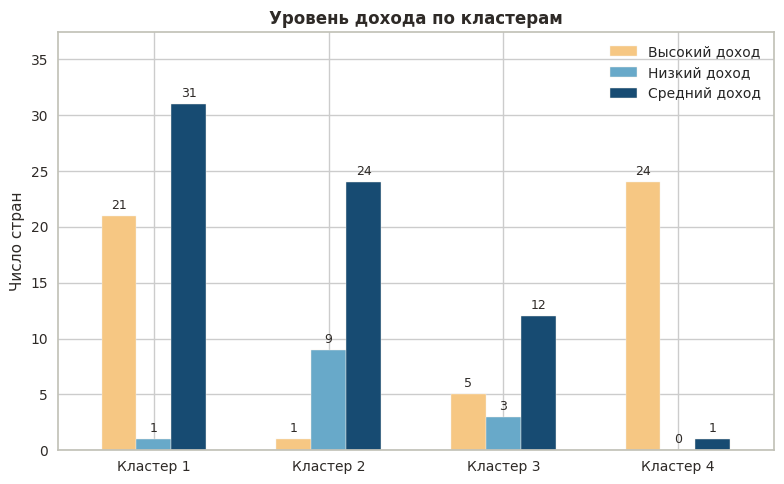

In [40]:
# Income
income_crosstab = pd.crosstab(df_cluster['cluster'], df_cluster['Income'])
income_crosstab.index = ['Кластер 1', 'Кластер 2', 'Кластер 3', 'Кластер 4']
income_crosstab.columns = ['Высокий доход', 'Низкий доход', 'Средний доход']

fig, ax = plt.subplots(figsize=(8, 5))
income_crosstab.plot(kind='bar', ax=ax, color=COMBO_5,
                     edgecolor=COLOR_LIGHT, width=0.6)
for container in ax.containers:
    ax.bar_label(container, fontsize=9, color=COLOR_DARK, padding=3)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.set_title('Уровень дохода по кластерам',
             fontsize=12, fontweight='bold', color=COLOR_DARK)
ax.set_ylabel('Число стран', fontsize=11, color=COLOR_DARK)
ax.tick_params(labelsize=10, colors=COLOR_DARK)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor(C_GREY)
plt.tight_layout()
plt.show()

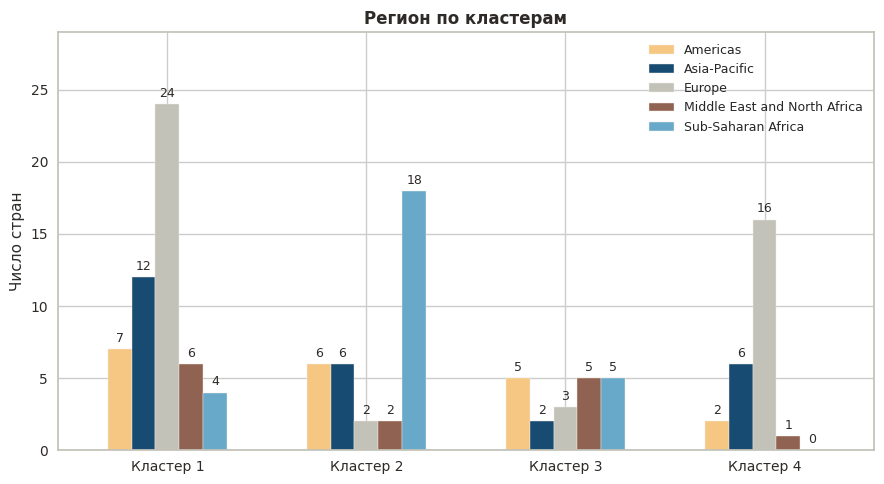

In [41]:
# Region2
PALETTE_REGION = [C_YELLOW, C_BLUE_D, C_GREY, C_BROWN, C_BLUE_L]

region_crosstab = pd.crosstab(df_cluster['cluster'], df_cluster['Region2'])
region_crosstab.index = ['Кластер 1', 'Кластер 2', 'Кластер 3', 'Кластер 4']

fig, ax = plt.subplots(figsize=(9, 5))
region_crosstab.plot(kind='bar', ax=ax, color=PALETTE_REGION,
                     edgecolor=COLOR_LIGHT, width=0.6)
for container in ax.containers:
    ax.bar_label(container, fontsize=9, color=COLOR_DARK, padding=3)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.set_title('Регион по кластерам',
             fontsize=12, fontweight='bold', color=COLOR_DARK)
ax.set_ylabel('Число стран', fontsize=11, color=COLOR_DARK)
ax.tick_params(labelsize=10, colors=COLOR_DARK)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(C_GREY)
plt.tight_layout()
plt.show()

По результатам апостериорного анализа кластерная структура хорошо
согласуется с категориальными переменными.

**Членство в ОЭСР**: практически все члены ОЭСР сосредоточены в Кластере 4
(23 из 25 стран). Это подтверждает, что инновационные лидеры и развитые
экономики совпадают. В Кластере 2 нет ни одного члена ОЭСР, в Кластерах
1 и 3 их 12 и 3 соответственно.

**Уровень дохода**: Кластер 4 почти полностью состоит из стран с высоким
доходом (24 из 25). Кластер 2, преимущественно страны со средним и
низким доходом (24 и 9 стран), что логично для аутсайдеров по инновациям.
Кластер 1, в основном страны со средним доходом (31 страна), что
согласуется с названием "формирующиеся экономики". Кластер 3, смесь
среднего и высокого дохода без явного доминирования.

**Регион**: в Кластере 4 доминирует Европа (16 из 25 стран). Кластер 2
почти полностью состоит из стран Sub-Saharan Africa (18 стран). Кластер 1
самый разнородный: Европа (24), Азия (12), Латинская Америка (7),
Ближний Восток (6). Кластер 3 не имеет явного регионального доминирования.

5. Почему получилась именно такая кластерная структура? Полученные результаты соответствуют вашем изначальным предположениям или оказались неожиданными?

## Задание 5 Интерпретация результатов

Полученная кластерная структура выглядит логичной и в целом совпадает с ожиданиями. Страны разделились по уровню инновационного развития: от явных лидеров до аутсайдеров. И это хорошо подтверждается апостериорным анализом: состав кластеров по доходу, региону и членству в ОЭСР соответствует их названиям.

Неожиданным оказался Кластер 3: страны с высокими расходами на образование, но средними результатами по остальным показателям. Это интересный результат: вложения в образование сами по себе не гарантируют высокого инновационного потенциала.

### Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение других алгоритмов кластеризации и их применение для анализа данных, или развернутое и глубокое исследование имеющихся данных на основе применения всех пройденных на занятиях алгоритмов кластеризации, сравнение результатов и выбор лучшей кластерной модели с объяснением своего выбора.
 - В этом задании пять пунктов. Первый весит 20%, второй - 5%, третий - 60%, четвертый - 10%, пятый - 5%.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и отправить на amelikyan@hse.ru до 23:55 20 марта.